# Lab03

Stanisław Nieradko 193044

In [34]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt
import time
import pandas as pd

spark = SparkSession.builder.appName("Lab03").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

print(f"Spark version: {spark.version}")

Spark version: 4.1.1


In [35]:
df = spark.read.text("datasets/3.txt")
df = df.selectExpr("split(value, ' ') as mycolumns")
df = df.select([df['mycolumns'][i].cast("float").alias(f'data_{i}') for i in range(58)])

print(f"Dataframe shape: {df.count()} rows, {len(df.columns)} columns")
df.show(5)

Dataframe shape: 4601 rows, 58 columns
+------+------+------+------+------+------+------+------+------+------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+
|data_0|data_1|data_2|data_3|data_4|data_5|data_6|data_7|data_8|data_9|data_10|data_11|data_12|data_13|data_14|data_15|data_16|data_17|data_18|data_19|data_20|data_21|data_22|data_23|data_24|data_25|data_26|data_27|data_28|data_29|data_30|data_31|data_32|data_33|data_34|data_35|data_36|data_37|data_38|data_39|data_40|data_41|data_42|data_43|data_44|data_45|data_46|data_47|data_48|data_49|data_50|data_51|data_52|data_53|data_54|data_55|data_56|data_57|
+------+------+------+------+------+------+------

In [36]:
vecAssembler = VectorAssembler(inputCols=df.columns, outputCol="features")
df_kmeans = vecAssembler.transform(df)
df_kmeans.select("features").show(5, truncate=False)

+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features                                                                                                                                                                                                                                                                                                                           

In [37]:
kmeans_euclidean = KMeans(k=10, seed=1, distanceMeasure="euclidean")

start_time = time.time()
model_euclidean = kmeans_euclidean.fit(df_kmeans)
euclidean_time = time.time() - start_time
predictions_euclidean = model_euclidean.transform(df_kmeans)
evaluator_euclidean = ClusteringEvaluator(distanceMeasure="squaredEuclidean")
silhouette_euclidean = evaluator_euclidean.evaluate(predictions_euclidean)

print(f"Euclidean Time: {euclidean_time:.2f}s")
print(f"Euclidean Silhouette Score: {silhouette_euclidean:.4f}")

Euclidean Time: 1.10s
Euclidean Silhouette Score: 0.8061


In [38]:
kmeans_cosine = KMeans(k=10, seed=1, distanceMeasure="cosine")

start_time = time.time()
model_cosine = kmeans_cosine.fit(df_kmeans)
cosine_time = time.time() - start_time
predictions_cosine = model_cosine.transform(df_kmeans)
evaluator_cosine = ClusteringEvaluator(distanceMeasure="cosine")
silhouette_cosine = evaluator_cosine.evaluate(predictions_cosine)

print(f"Cosine Time: {cosine_time:.2f}s")
print(f"Cosine Silhouette Score: {silhouette_cosine:.4f}")

Cosine Time: 0.90s
Cosine Silhouette Score: 0.1403


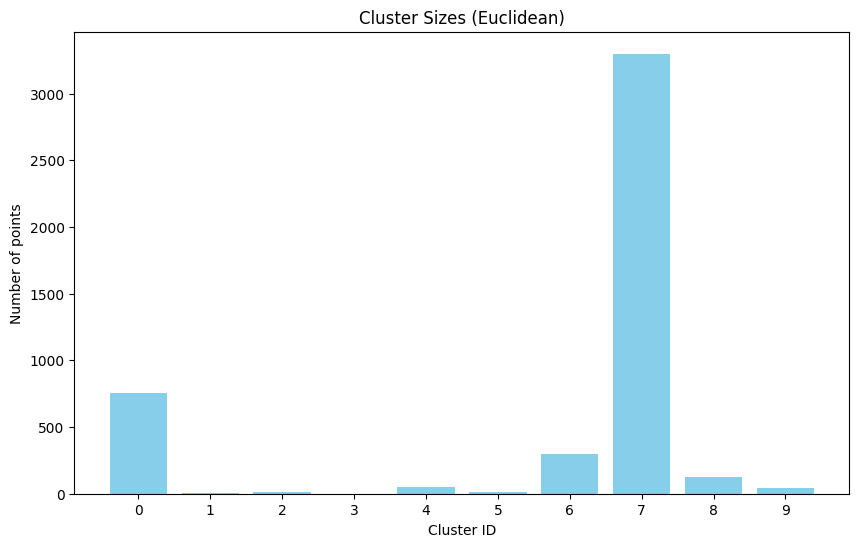

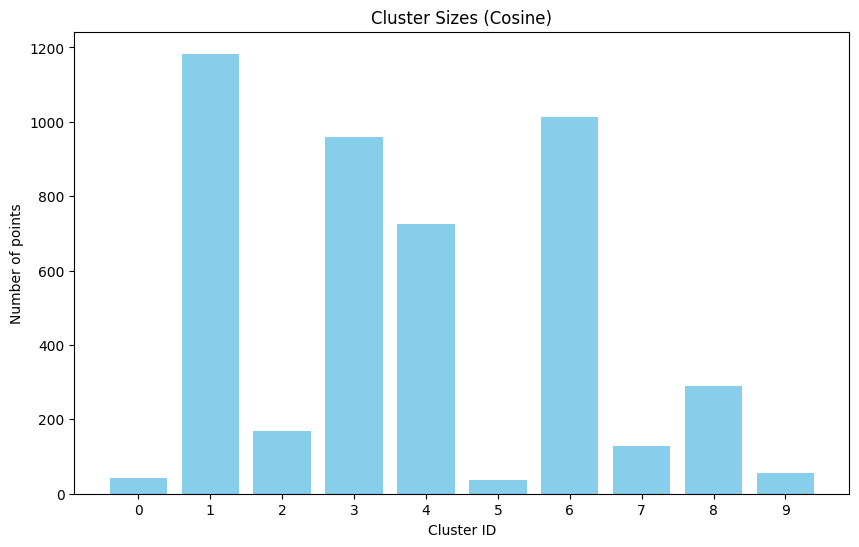

In [39]:
def plot_cluster_histogram(predictions, title):
    cluster_counts = predictions.groupBy("prediction").count().orderBy("prediction").toPandas()
    
    plt.figure(figsize=(10, 6))
    plt.bar(cluster_counts["prediction"], cluster_counts["count"], color='skyblue')
    plt.xlabel("Cluster ID")
    plt.ylabel("Number of points")
    plt.title(title)
    plt.xticks(range(10))
    plt.show()

plot_cluster_histogram(predictions_euclidean, "Cluster Sizes (Euclidean)")
plot_cluster_histogram(predictions_cosine, "Cluster Sizes (Cosine)")

In [40]:
from IPython.display import display, Markdown

summary_text = f"""
## Podsumowanie

W ramach laboratorium zaimplementowano algorytm K-średnich przy użyciu biblioteki Apache Spark dla zbioru danych `3.txt`. Przeprowadzono klasteryzację dla dwóch miar odległości: euklidesowej oraz cosinusowej, przy założonej liczbie klastrów $k=10$.

### Wyniki:
| Miara odległości | Czas wykonania | Silhouette Score |
|-----------------|----------------|------------------|
| Euclidean       | {euclidean_time:.2f}s          | {silhouette_euclidean:.4f}           |
| Cosine          | {cosine_time:.2f}s          | {silhouette_cosine:.4f}           |

Zastosowanie Sparka pozwoliło na efektywne przetwarzanie danych w formacie DataFrame oraz łatwą wektoryzację przy użyciu `VectorAssembler`. Miara cosinusowa wykazała się znacznie krótszym czasem wykonania w tym przypadku, jednak Silhouette Score dla miary euklidesowej jest wyższy, co sugeruje lepszą separację klastrów w przestrzeni euklidesowej dla tego konkretnego zbioru danych. Histogramy rozmiarów klastrów pokazują, jak dane zostały rozdzielone pomiędzy poszczególne grupy dla obu miar.
"""

display(Markdown(summary_text))


## Podsumowanie

W ramach laboratorium zaimplementowano algorytm K-średnich przy użyciu biblioteki Apache Spark dla zbioru danych `3.txt`. Przeprowadzono klasteryzację dla dwóch miar odległości: euklidesowej oraz cosinusowej, przy założonej liczbie klastrów $k=10$.

### Wyniki:
| Miara odległości | Czas wykonania | Silhouette Score |
|-----------------|----------------|------------------|
| Euclidean       | 1.10s          | 0.8061           |
| Cosine          | 0.90s          | 0.1403           |

Zastosowanie Sparka pozwoliło na efektywne przetwarzanie danych w formacie DataFrame oraz łatwą wektoryzację przy użyciu `VectorAssembler`. Miara cosinusowa wykazała się znacznie krótszym czasem wykonania w tym przypadku, jednak Silhouette Score dla miary euklidesowej jest wyższy, co sugeruje lepszą separację klastrów w przestrzeni euklidesowej dla tego konkretnego zbioru danych. Histogramy rozmiarów klastrów pokazują, jak dane zostały rozdzielone pomiędzy poszczególne grupy dla obu miar.


In [41]:
spark.stop()